# 11 — Train Audio Model

Fine-tunes every model in `config.AUDIO_MODELS_TO_RUN` on the MELD training
set using raw waveforms, and saves the best checkpoint (by dev macro-F1).

**Depends on:** `02_preprocess_audio.ipynb` (run automatically below).

**Trim parameters** are read from `src/config.py` (`TRIM_START_S`, `TRIM_END_S`).
To experiment with different values without editing the config, override them
in the cell marked *optional overrides* below.

**Outputs** (written to `../experiments/audio_unimodal/<version>/<model_slug>/`):
- `model/`             — best checkpoint + feature extractor
- `history.csv`        — per-epoch train/dev metrics
- `config.json`        — full run config (includes trim/max_audio settings)
- `train_metrics.json` — summary (params, time, power, best dev F1)
- `power_samples.csv`  — raw GPU power readings

e:\Licenta\Multimodal-Emotion-Recognition---Bachelor-Thesis\.venv\Lib\site-packages\nbformat\__init__.py:96: MissingIDFieldWarning: Cell is missing an id field, this will become a hard error in future nbformat versions. You may want to use `normalize()` on your notebooks before validations (available since nbformat 5.1.4). Previous versions of nbformat are fixing this issue transparently, and will stop doing so in the future.
  validate(nb)
e:\Licenta\Multimodal-Emotion-Recognition---Bachelor-Thesis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Label map: {'anger': 0, 'disgust': 1, 'fear': 2, 'happiness': 3, 'neutral': 4, 'sadness': 5, 'surprise': 6}
Train: 9,988 | Dev: 1,108 | Test: 2,610
Duration stats (sampled 500 files):
  mean  : 3.23 s
  median: 2.43 s
  max   : 41.05 s
  >MAX_AUDIO_S (10.0s): 14 clips


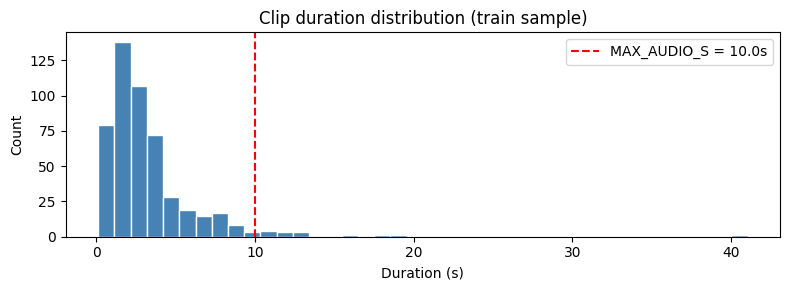

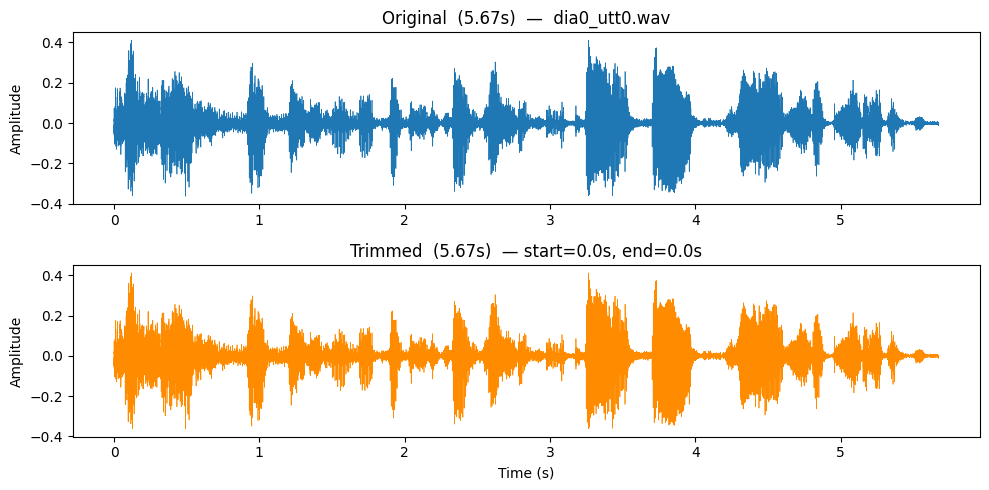

[train] OK — 9,988 rows
[dev] OK — 1,108 rows
[test] OK — 2,610 rows


In [1]:
# Imports train_df_audio, dev_df_audio, test_df_audio, label2id, id2label
%run 02_preprocess_audio.ipynb

In [2]:
from src.config import AUDIO_MODELS_TO_RUN, DEVICE, TRIM_START_S, TRIM_END_S, MAX_AUDIO_S
from src.training.train_audio import train_one_audio

print('Device:', DEVICE)
print('Models to train:', AUDIO_MODELS_TO_RUN)

Device: cuda
Models to train: ['facebook/wav2vec2-base', 'ntu-spml/distilhubert']


## Optional — override trim / max-duration for this run

Change the values below and re-run the training cell.
Leave as-is to use whatever is set in `src/config.py`.

In [3]:
# Override here if you want to experiment without touching config.py:
trim_start_s = 0.3   # e.g. 0.5 to remove the first 500 ms
trim_end_s   = 0.3     # e.g. 0.5 to remove the last  500 ms
max_audio_s  = MAX_AUDIO_S    # e.g. 8.0 to cap clips at 8 seconds

print(f'Trim start : {trim_start_s}s')
print(f'Trim end   : {trim_end_s}s')
print(f'Max audio  : {max_audio_s}s')

Trim start : 0.3s
Trim end   : 0.3s
Max audio  : 10.0s


## Train

In [4]:
run_dirs = []

for model_name in AUDIO_MODELS_TO_RUN:
    run_dir = train_one_audio(
        model_name=model_name,
        train_df=train_df_audio,
        dev_df=dev_df_audio,
        test_df=test_df_audio,
        label2id=label2id,
        id2label=id2label,
        trim_start_s=trim_start_s,
        trim_end_s=trim_end_s,
        max_audio_s=max_audio_s,
    )
    run_dirs.append(run_dir)

print('\nAll run directories:')
for d in run_dirs:
    print(' ', d)

Loading weights: 100%|██████████| 211/211 [00:00<00:00, 1016.31it/s, Materializing param=wav2vec2.masked_spec_embed]                                            
Wav2Vec2ForSequenceClassification LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     | 
-----------------------------+------------+-
quantizer.weight_proj.bias   | UNEXPECTED | 
project_hid.weight           | UNEXPECTED | 
quantizer.weight_proj.weight | UNEXPECTED | 
project_hid.bias             | UNEXPECTED | 
project_q.bias               | UNEXPECTED | 
project_q.weight             | UNEXPECTED | 
quantizer.codevectors        | UNEXPECTED | 
projector.weight             | MISSING    | 
classifier.weight            | MISSING    | 
projector.bias               | MISSING    | 
classifier.bias              | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because mis

No prgress in 1 epochs.


facebook_wav2vec2_base | epoch 7/200: 100%|██████████| 1249/1249 [05:58<00:00,  3.48it/s]
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.69it/s]
facebook_wav2vec2_base | epoch 8/200: 100%|██████████| 1249/1249 [05:59<00:00,  3.47it/s]


No prgress in 1 epochs.


facebook_wav2vec2_base | epoch 9/200: 100%|██████████| 1249/1249 [06:07<00:00,  3.40it/s]
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.83it/s]
facebook_wav2vec2_base | epoch 10/200: 100%|██████████| 1249/1249 [05:58<00:00,  3.48it/s]
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.62it/s]
facebook_wav2vec2_base | epoch 11/200: 100%|██████████| 1249/1249 [06:07<00:00,  3.40it/s]
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.79it/s]
facebook_wav2vec2_base | epoch 12/200: 100%|██████████| 1249/1249 [06:08<00:00,  3.39it/s]


...

No prgress in 3 epochs.


ntu_spml_distilhubert | epoch 17/200: 100%|██████████| 1249/1249 [02:39<00:00,  7.85it/s]


No prgress in 4 epochs.


ntu_spml_distilhubert | epoch 18/200: 100%|██████████| 1249/1249 [02:34<00:00,  8.07it/s]


No prgress in 5 epochs.
Early stopping at epoch 18!

[DONE] ntu-spml/distilhubert  →  ../experiments/audio_unimodal\v2\ntu_spml_distilhubert
  Best dev macro-F1 : 0.2085  (epoch 13)

All run directories:
  ../experiments/audio_unimodal\v2\facebook_wav2vec2_base
  ../experiments/audio_unimodal\v2\ntu_spml_distilhubert


## Quick peek at training history

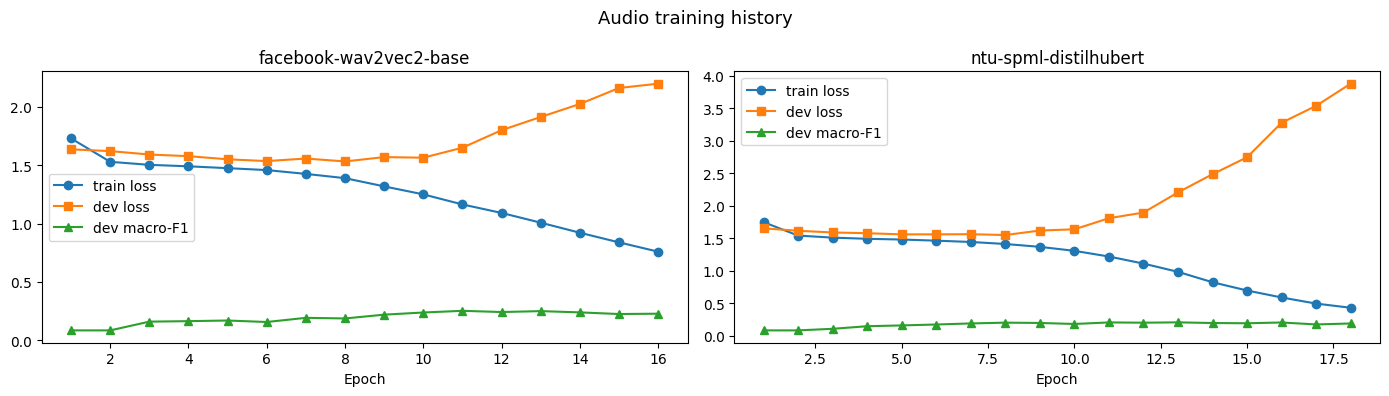

: 

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(run_dirs), figsize=(7 * len(run_dirs), 4), squeeze=False)

for ax, run_dir in zip(axes[0], run_dirs): 
    history_path = os.path.join(run_dir, 'history.csv')
    if not os.path.exists(history_path):
        continue
    hist = pd.read_csv(history_path)
    ax.plot(hist['epoch'], hist['train_loss'],   label='train loss',   marker='o')
    ax.plot(hist['epoch'], hist['dev_loss'],     label='dev loss',     marker='s')
    ax.plot(hist['epoch'], hist['dev_macro_f1'], label='dev macro-F1', marker='^')
    ax.set_xlabel('Epoch')
    ax.set_title(os.path.basename(run_dir).replace('_', '-'))
    ax.legend()

plt.suptitle('Audio training history', fontsize=13)
plt.tight_layout()
plt.show()